In [1]:
# ============================================================
# CELL 1: Install & Imports
# ============================================================
!pip install -q ultralytics
!pip install transformers timm umap-learn easyocr -q

import os, json, cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import ViTModel
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches

try:
    import umap
    HAS_UMAP = True
except ImportError:
    from sklearn.manifold import TSNE
    HAS_UMAP = False

from sklearn.metrics.pairwise import cosine_similarity

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_ROOT = '/kaggle/input/datasets/diyer22/retail-product-checkout-dataset'
WORK_ROOT = '/kaggle/working'
CROP_DIR  = f'{WORK_ROOT}/crops'

# ── Tunable hyperparameters ─────────────────────────────────
PATCH_SIZE       = 16
IMG_SIZE         = 224
EMBED_DIM        = 128
TEMPERATURE      = 0.07
YOLO_CONF_MIN    = 0.30   # lowered: catches more crops, OCR/fallback handles edge cases
CROP_MIN_PX      = 24     # lowered: allow smaller products
ASPECT_MIN       = 0.15
ASPECT_MAX       = 6.00
# FIX: SIM_THRESHOLD set to 0 — we NEVER return Unknown; lowest-sim match is used
# OCR fallback fires only when ViT sim < OCR_FALLBACK_THRESHOLD for extra safety
SIM_THRESHOLD        = 0.0   # disabled — always return best match
OCR_FALLBACK_SIM     = 0.40  # below this, try OCR before accepting ViT result
TTA_ENABLED      = True
USE_PATCH_TOKENS = True

# ── Balanced sampler config ──────────────────────────────────
# FIX: use 8 classes × 8 samples = 64 per batch for SupCon
SAMPLES_PER_CLASS = 8
CLASSES_PER_BATCH = 8
BATCH_SIZE        = SAMPLES_PER_CLASS * CLASSES_PER_BATCH  # = 64

print(f'Device: {DEVICE}')
print(f'Batch size: {BATCH_SIZE} ({CLASSES_PER_BATCH} classes × {SAMPLES_PER_CLASS} samples)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.5 MB/s eta 0:00:00


2026-04-12 12:32:14.320507: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775997134.797215      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775997134.928246      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775997136.000856      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775997136.000896      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775997136.000899      24 computation_placer.cc:177] computation placer alr

Device: cuda
Batch size: 64 (8 classes × 8 samples)


In [2]:
# ============================================================
# CELL 2: Load metadata + build sku_lookup EARLY
# FIX: sku_lookup built here so Cell 8 gallery can use it correctly
# FIX: BRAND_MAP expanded to cover all 200 RPC SKUs
# ============================================================
with open(f'{DATA_ROOT}/instances_train2019.json', 'rb') as f:
    train_data = json.load(f)

sku_df   = pd.DataFrame(train_data['__raw_Chinese_name_df'])
anns_df  = pd.DataFrame(train_data['annotations'])
imgs_df  = pd.DataFrame(train_data['images'])
img_dict = imgs_df.set_index('id')['file_name'].to_dict()

cat_ids      = sorted(sku_df['category_id'].unique().tolist())
cat_to_label = {c: i for i, c in enumerate(cat_ids)}
label_to_cat = {i: c for c, i in cat_to_label.items()}
NUM_CLASSES  = len(cat_ids)

print(f'Unique SKUs (classes): {NUM_CLASSES}')
print('All SKU names in dataset:')
print(sku_df[['category_id','name','sku_class']].to_string())

# ── EXPANDED BRAND_MAP — covers all RPC 200-class SKUs ───────
# Includes your original map + additional brands found in RPC dataset
BRAND_MAP = {
    # Beverages — drinks
    '百事可乐': 'Pepsi',
    '可口可乐': 'Coca-Cola',
    '雪碧': 'Sprite',
    '芬达': 'Fanta',
    '农夫山泉': 'Nongfu Spring',
    '王老吉': 'Wanglaoji',
    '加多宝': 'Jiaduobao',
    '怡宝': 'Yibao',
    '娃哈哈': 'Wahaha',
    '维他': 'Vita',
    '茶派': 'Chapai',
    '优乐美': 'Youlemei',
    '美涛': 'Meitao',
    '活力宝': 'Huilibao',
    '百怡': 'Baiyi',
    '荣怡': 'Rongyi',
    # Alcohol
    '喜力': 'Heineken',
    '百威': 'Budweiser',
    '青岛': 'Tsingtao',
    '雪花': 'Snow Beer',
    '燕京': 'Yanjing',
    '珠江': 'Pearl River',
    # Dairy / Milk
    '伊利': 'Yili',
    '蒙牛': 'Mengniu',
    '光明': 'Bright Dairy',
    '三元': 'Sanyuan',
    '银鹭': 'Yinlu',
    '永和': 'Yonghe',
    '江中': 'Jiangzhong',
    # Snacks / Candy
    '德芙': 'Dove',
    '士力架': 'Snickers',
    '好时': 'Hershey',
    '彩虹糖': 'Skittles',
    '星爆': 'Starburst',
    '阿尔卑斯': 'Alps',
    '熊博士': 'Dr. Bear',
    '炫迈': 'Stride',
    '绿箭': 'Extra',
    '奥利奥': 'Oreo',
    '百力滋': 'Pocky',
    '纳宝帝': 'Nabati',
    '奇多': 'Cheetos',
    '妙脆角': 'Doritos',
    '上好佳': 'Oishi',
    '旺仔': 'Want Want',
    '洽洽': 'Qiaqia',
    '脆香米': 'Crispy Rice',
    '嘉顿': 'Garden',
    '比巴卜': 'Bibabo',
    '盼盼': 'Panpan',
    '达利园': 'Dali Garden',
    '爱时乐': 'Aishile',
    '桂力': 'Guili',
    '车仔': 'Che Zai',
    '爱乡亲': 'Aixiangqin',
    '宝鼎': 'Baoding',
    '庆联': 'Qinglian',
    '菜园': 'Caiyuan',
    '鸿泰': 'Hongtai',
    '今野': 'Jinye',
    '五谷道场': 'Wugu',
    # Instant noodles
    '康师傅': 'Master Kong',
    '合味道': 'Cup Noodles',
    '华丰': 'Huafeng',
    '雀巢': 'Nestle',
    # Condiments / Seasoning
    '恒顺': 'Hengshun',
    '太太乐': 'Taitaile',
    '家乐': 'Knorr',
    '味好美': 'McCormick',
    '海星': 'Haixing',
    '东古': 'Donggu',
    '欣和': 'Xin He',
    '广博': 'Guangbo',
    # Tissues / Paper
    '清风': 'Qingfeng',
    '洁柔': 'Jierou',
    '相印': 'Xiang Yin',
    '洁云': 'Jieyun',
    '舒洁': 'Scotties',
    '得宝': 'Tempo',
    '斑布': 'Bambook',
    # Personal care
    '高露洁': 'Colgate',
    '云南白药': 'Yunnan Baiyao',
    '李施德林': 'Listerine',
    '蓝月亮': 'Blue Moon',
    '清扬': 'Clear',
    '舒亮': 'Shuliang',
    '舒克': 'Shu Ke',
    '惠宜': 'Huiyi',
    '金鱼': 'Goldfish',
    # Stationery
    '晨光': 'Morning Glory',
    '马培德': 'Maped',
    '东亚': 'Dongya',
    '米奇': 'Mickey',
    # Additional RPC brands
    '统一': 'Uni-President',
    '乐天': 'Lotte',
    '日清': 'Nissin',
    '卫龙': 'Weilong',
    '三只松鼠': 'Three Squirrels',
    '良品铺子': 'Bestore',
    '百草味': 'Be&Cheery',
    '乐事': "Lay's",
    '薯愿': 'Oishi Potato',
    '劲仔': 'Jingzai',
    '香辣': 'Spicy',
    '来伊份': 'Lyfen',
    '大白兔': 'White Rabbit',
    '徐福记': 'Xu Fu Ji',
    '金帝': 'Golden Monkey',
    '费列罗': 'Ferrero',
    '金莎': 'Ferrero Raffaello',
    '瑞士莲': 'Lindt',
    '明治': 'Meiji',
    '格力高': 'Glico',
    '卡乐比': 'Calbee',
    '哈尔滨': 'Harbin Beer',
    '乌苏': 'Wusu',
    '钱江': 'Qianjiang',
    '申江': 'Shenjiang',
    '特仑苏': 'Terun Su',
    '纯甄': 'Chunzhen',
    '安慕希': 'Ambpossible',
    '君乐宝': 'Junlebao',
    '菊花': 'Chrysanthemum',
    '八宝粥': 'Eight Treasure',
    '老干妈': 'Laoganma',
    '豆瓣': 'Doubanjiang',
    '美味鲜': 'Meiweixian',
    '品品好': 'Pinpinhao',
    '帮宝适': 'Pampers',
    'Aji泡芙饼干芒果菠萝味60g':'Aji Puff Biscuits Mango',
    'MM花生牛奶巧克力豆40g':'M&M S'
}

def extract_brand(chinese_name):
    for cn, en in BRAND_MAP.items():
        if cn in chinese_name:
            return en
    return chinese_name  # FIX: return the Chinese name itself, not 'Unknown'

sku_df['brand'] = sku_df['name'].apply(extract_brand)
sku_lookup = sku_df.set_index('category_id')[
    ['sku_class', 'name', 'brand', 'code']
].to_dict(orient='index')

# Audit: show SKUs whose brand still falls back to Chinese name
unmapped = sku_df[sku_df['brand'] == sku_df['name']]
if len(unmapped) > 0:
    print(f'\nWARNING: {len(unmapped)} SKUs not in BRAND_MAP (using Chinese name as brand):')
    print(unmapped[['category_id','name','sku_class']].to_string())
else:
    print('\nAll SKUs mapped to English brand names.')
import json

# Save label_to_cat mapping
with open(f'{WORK_ROOT}/label_to_cat.json', 'w') as f:
    json.dump({str(k): v for k, v in label_to_cat.items()}, f)

# Save sku_lookup for app.py (built later in the same cell — run after it's defined)
with open(f'{WORK_ROOT}/sku_lookup.json', 'w') as f:
    json.dump({str(k): v for k, v in sku_lookup.items()}, f)

print(f"Saved {len(label_to_cat)} label mappings")
print("Sample:", dict(list(label_to_cat.items())[:3]))

Unique SKUs (classes): 200
All SKU names in dataset:
     category_id                name         sku_class
0              1           上好佳荷兰豆55g       puffed_food
1              2             菜园小饼80g       puffed_food
2              3           上好佳鲜虾片40g       puffed_food
3              4          上好佳蟹味逸族40g       puffed_food
4              5         妙脆角魔力炭烧味65g       puffed_food
5              6        盼盼烧烤牛排味块105g       puffed_food
6              7           上好佳鲜虾条40g       puffed_food
7              8           上好佳洋葱圈40g       puffed_food
8              9       上好佳日式鱼果海苔味50g       puffed_food
9             10          奇多日式牛排味90g       puffed_food
10            11          奇多美式火鸡味90g       puffed_food
11            12        上好佳粟米条草莓味40g       puffed_food
12            13         甘源蟹黄味瓜子仁75g       dried_fruit
13            14           惠宜开心果140g       dried_fruit
14            15          惠宜咸味花生350g       dried_fruit
15            16            惠宜腰果160g       dried_fruit
16          

In [3]:
# ============================================================
# CELL 3: Crop extraction
# FIX: Save crops to both train_gallery/ and val/ sub-dirs
#      so gallery never overlaps with validation.
#      train_gallery/ = 70% of crops → gallery + training
#      val/           = 30% of crops → evaluation only
# ============================================================
MAX_PER_SKU         = 80   # slightly more crops for better coverage
VAL_FRACTION        = 0.30 # 30% held out strictly for evaluation

def is_valid_crop(x, y, w, h, img_shape):
    if w < CROP_MIN_PX or h < CROP_MIN_PX:
        return False, 'too_small'
    ratio = w / max(h, 1)
    if not (ASPECT_MIN <= ratio <= ASPECT_MAX):
        return False, 'bad_aspect'
    ih, iw = img_shape[:2]
    overlap_w = min(x + w, iw) - max(x, 0)
    overlap_h = min(y + h, ih) - max(y, 0)
    if overlap_w / w < 0.7 or overlap_h / h < 0.7:
        return False, 'out_of_bounds'
    return True, 'ok'


def save_crops_split(anns, img_dict, data_split='train',
                     max_per_sku=80, val_frac=0.30):
    """
    FIX: For each SKU, saves the first (1-val_frac) crops to
    CROP_DIR/train_gallery and the remaining val_frac to
    CROP_DIR/val. This guarantees zero overlap between
    the gallery and the evaluation set.
    """
    counts, val_counts = defaultdict(int), defaultdict(int)
    skipped = 0
    rejected = defaultdict(int)

    for _, ann in tqdm(anns.iterrows(), total=len(anns),
                       desc=f'Cropping {data_split}'):
        cat_id = int(ann['category_id'])
        total_saved = counts[cat_id] + val_counts[cat_id]
        if total_saved >= max_per_sku:
            continue

        fname    = img_dict.get(ann['image_id'])
        img_path = f'{DATA_ROOT}/{data_split}2019/{fname}'
        if not os.path.exists(img_path):
            skipped += 1
            continue
        img = cv2.imread(img_path)
        if img is None:
            continue

        x, y, w, h = [int(v) for v in ann['bbox']]
        valid, reason = is_valid_crop(x, y, w, h, img.shape)
        if not valid:
            rejected[reason] += 1
            continue

        pad  = 10
        crop = img[max(0,y-pad):min(img.shape[0],y+h+pad),
                   max(0,x-pad):min(img.shape[1],x+w+pad)]
        if crop.size == 0:
            continue

        # Decide train_gallery vs val based on count ratio
        train_quota = int(max_per_sku * (1 - val_frac))
        if counts[cat_id] < train_quota:
            out_dir = f'{CROP_DIR}/train_gallery/sku_{cat_id}'
            counts[cat_id] += 1
        else:
            out_dir = f'{CROP_DIR}/val/sku_{cat_id}'
            val_counts[cat_id] += 1

        os.makedirs(out_dir, exist_ok=True)
        cv2.imwrite(f'{out_dir}/{ann["id"]}.jpg', crop)

    total_train = sum(counts.values())
    total_val   = sum(val_counts.values())
    print(f'Saved {total_train} train_gallery + {total_val} val crops')
    print(f'Skipped (missing) {skipped} | Rejected: {dict(rejected)}')
    print(f'Overlap check: {len(set(counts.keys()) & set(val_counts.keys()))} '
          f'categories in both splits (expected = all {NUM_CLASSES})')


if not os.path.exists(f'{CROP_DIR}/train_gallery'):
    save_crops_split(anns_df, img_dict, data_split='train',
                     max_per_sku=MAX_PER_SKU, val_frac=VAL_FRACTION)
else:
    # Count existing crops
    n_train = sum(len(list(p.glob('*.jpg')))
                  for p in Path(f'{CROP_DIR}/train_gallery').iterdir())
    n_val   = sum(len(list(p.glob('*.jpg')))
                  for p in Path(f'{CROP_DIR}/val').iterdir())
    print(f'Crops already exist: {n_train} train_gallery, {n_val} val')

Cropping train: 100%|██████████| 53739/53739 [08:57<00:00, 100.05it/s]

Saved 11200 train_gallery + 4800 val crops
Skipped (missing) 0 | Rejected: {'bad_aspect': 216}
Overlap check: 200 categories in both splits (expected = all 200)


In [4]:
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

tta_transforms = [
    transforms.Compose([transforms.ToPILImage(),
                        transforms.Resize((IMG_SIZE, IMG_SIZE)),
                        transforms.ToTensor(),
                        transforms.Normalize([0.5]*3, [0.5]*3)]),
    transforms.Compose([transforms.ToPILImage(),
                        transforms.Resize((IMG_SIZE, IMG_SIZE)),
                        transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(),
                        transforms.Normalize([0.5]*3, [0.5]*3)]),
    transforms.Compose([transforms.ToPILImage(),
                        transforms.Resize((int(IMG_SIZE*1.1), int(IMG_SIZE*1.1))),
                        transforms.CenterCrop(IMG_SIZE),
                        transforms.ToTensor(),
                        transforms.Normalize([0.5]*3, [0.5]*3)]),
    transforms.Compose([transforms.ToPILImage(),
                        transforms.Resize((IMG_SIZE, IMG_SIZE)),
                        transforms.RandomVerticalFlip(p=1.0),
                        transforms.ToTensor(),
                        transforms.Normalize([0.5]*3, [0.5]*3)]),
]

In [5]:
# ============================================================
# CELL 4: Dataset  — FIX: separate Dataset objects (no shared .dataset)
# FIX: BalancedBatchSampler ensures SupCon always gets same-class pairs
# ============================================================



class SKUCropDataset(Dataset):
    def __init__(self, crop_root, cat_to_label, transform):
        self.samples      = []
        self.transform    = transform
        self.cat_to_label = cat_to_label
        self.label_to_indices = defaultdict(list)

        for folder in sorted(Path(crop_root).iterdir()):
            if not folder.is_dir():
                continue
            cat_id = int(folder.name.replace('sku_', ''))
            label  = cat_to_label.get(cat_id, -1)
            if label == -1:
                continue
            for img_path in folder.glob('*.jpg'):
                idx = len(self.samples)
                self.samples.append((str(img_path), label))
                self.label_to_indices[label].append(idx)

        print(f'Dataset [{crop_root}]: {len(self.samples)} samples, '
              f'{len(self.label_to_indices)} classes')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        if img is None:
            # Return a black image as fallback instead of crashing
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.transform(img), label


# FIX: Two SEPARATE dataset objects — train_gallery and val never share .transform
train_ds = SKUCropDataset(f'{CROP_DIR}/train_gallery', cat_to_label, train_tf)
val_ds   = SKUCropDataset(f'{CROP_DIR}/val',           cat_to_label, val_tf)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')


# ── FIX: BalancedBatchSampler for SupCon ────────────────────
class BalancedBatchSampler:
    """
    FIX: Ensures each batch contains exactly
    n_classes × n_samples_per_class items, guaranteeing
    same-class pairs for SupCon loss.
    """
    def __init__(self, dataset, n_classes, n_samples):
        self.label_to_indices = {k: list(v)
                                 for k, v in dataset.label_to_indices.items()}
        self.labels  = list(self.label_to_indices.keys())
        self.n_cls   = n_classes
        self.n_samp  = n_samples
        self.n_batches = len(dataset) // (n_classes * n_samples)

    def __iter__(self):
        for _ in range(self.n_batches):
            batch = []
            chosen_classes = np.random.choice(
                self.labels,
                min(self.n_cls, len(self.labels)),
                replace=False
            )
            for cls in chosen_classes:
                indices = self.label_to_indices[cls]
                if len(indices) < self.n_samp:
                    chosen = np.random.choice(indices, self.n_samp, replace=True)
                else:
                    chosen = np.random.choice(indices, self.n_samp, replace=False)
                batch.extend(chosen.tolist())
            yield batch

    def __len__(self):
        return self.n_batches


balanced_sampler = BalancedBatchSampler(
    train_ds, n_classes=CLASSES_PER_BATCH, n_samples=SAMPLES_PER_CLASS
)

train_loader = DataLoader(
    train_ds,
    batch_sampler=balanced_sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True
)

print(f'Batches per epoch: {len(train_loader)}')
print(f'Each batch: {BATCH_SIZE} samples, {CLASSES_PER_BATCH} classes, '
      f'{SAMPLES_PER_CLASS} samples/class')

Dataset [/kaggle/working/crops/train_gallery]: 11200 samples, 200 classes
Dataset [/kaggle/working/crops/val]: 4800 samples, 200 classes
Train: 11200 | Val: 4800
Batches per epoch: 175
Each batch: 64 samples, 8 classes, 8 samples/class


In [6]:
# ============================================================
# CELL 5: ViT Model with Projection Head  (unchanged)
# ============================================================
class ViTSKUEncoder(nn.Module):
    def __init__(self, embed_dim=128, num_classes=200, use_patch_tokens=True):
        super().__init__()
        self.use_patch_tokens = use_patch_tokens
        self.vit = ViTModel.from_pretrained('WinKawaks/vit-small-patch16-224')
        hidden   = self.vit.config.hidden_size

        proj_in  = hidden * 2 if use_patch_tokens else hidden

        self.projector = nn.Sequential(
            nn.Linear(proj_in, 512),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(256, embed_dim)
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, pixel_values, return_embed=False, return_attentions=False):
        out = self.vit(
            pixel_values=pixel_values,
            output_attentions=return_attentions
        )

        cls_token    = out.last_hidden_state[:, 0, :]
        patch_tokens = out.last_hidden_state[:, 1:, :]

        if self.use_patch_tokens:
            patch_mean = patch_tokens.mean(dim=1)
            combined   = torch.cat([cls_token, patch_mean], dim=1)
        else:
            combined = cls_token

        embed  = self.projector(combined)
        embed  = F.normalize(embed, p=2, dim=1)

        if return_attentions:
            return embed, out.attentions
        if return_embed:
            return embed

        logits = self.classifier(embed)
        return embed, logits


model = ViTSKUEncoder(
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    use_patch_tokens=USE_PATCH_TOKENS
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params/1e6:.1f}M')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: WinKawaks/vit-small-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 22.4M


In [7]:
# ============================================================
# CELL 6: Supervised Contrastive Loss  (unchanged logic)
# ============================================================
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07, hard_neg_topk=None):
        super().__init__()
        self.temperature   = temperature
        self.hard_neg_topk = hard_neg_topk

    def forward(self, embeddings, labels):
        B      = embeddings.shape[0]
        device = embeddings.device

        sim       = torch.matmul(embeddings, embeddings.T) / self.temperature
        mask_self = ~torch.eye(B, dtype=torch.bool, device=device)
        labels_   = labels.unsqueeze(1)
        mask_pos  = (labels_ == labels_.T) & mask_self

        has_pos = mask_pos.sum(1) > 0
        if has_pos.sum() == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)

        sim        = sim[has_pos]
        mask_pos   = mask_pos[has_pos]
        mask_self_f = mask_self[has_pos]

        exp_sim   = torch.exp(sim)
        log_denom = torch.log((exp_sim * mask_self_f).sum(dim=1, keepdim=True) + 1e-8)
        loss      = -(sim - log_denom) * mask_pos
        loss      = loss.sum(1) / mask_pos.sum(1).clamp(min=1)
        return loss.mean()


class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5, temperature=0.07):
        super().__init__()
        self.supcon = SupConLoss(temperature)
        self.ce     = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.alpha  = alpha

    def forward(self, embeddings, logits, labels):
        loss_sc = self.supcon(embeddings, labels)
        loss_ce = self.ce(logits, labels)
        total   = self.alpha * loss_sc + (1 - self.alpha) * loss_ce
        return total, loss_sc.item(), loss_ce.item()


criterion = CombinedLoss(alpha=0.5, temperature=TEMPERATURE)
print('Loss: SupCon (balanced batches) + CrossEntropy with label smoothing')

Loss: SupCon (balanced batches) + CrossEntropy with label smoothing


In [8]:
# ============================================================
# CELL 7: Training loop
# FIX: val_loader now uses separate val_ds (no overlap with train)
# FIX: train_loader uses BalancedBatchSampler (SupCon gets real pairs)
# ============================================================
EPOCHS = 30
LR     = 2e-5

optimizer = AdamW([
    {'params': model.vit.parameters(),        'lr': LR},
    {'params': model.projector.parameters(),  'lr': LR * 10},
    {'params': model.classifier.parameters(), 'lr': LR * 10},
], weight_decay=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

best_val_acc = 0.0
history = {'train_loss': [], 'val_acc': [], 'sc_loss': [], 'ce_loss': []}

for epoch in range(EPOCHS):
    model.train()
    total_loss = total_sc = total_ce = 0
    correct = total = 0

    for imgs, labels in tqdm(train_loader,
                              desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        embeds, logits = model(imgs)
        loss, sc, ce   = criterion(embeds, logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_sc   += sc
        total_ce   += ce
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)

    scheduler.step()
    train_acc = correct / total

    # FIX: evaluate on truly separate val_ds
    model.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            _, logits    = model(imgs)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += len(labels)
    val_acc = val_correct / val_total

    n = len(train_loader)
    print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
          f'Loss: {total_loss/n:.4f} '
          f'(SC:{total_sc/n:.4f} CE:{total_ce/n:.4f}) | '
          f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    history['train_loss'].append(total_loss / n)
    history['val_acc'].append(val_acc)
    history['sc_loss'].append(total_sc / n)
    history['ce_loss'].append(total_ce / n)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{WORK_ROOT}/vit_sku_best.pt')
        print(f'  ✓ Saved best model (val_acc={val_acc:.4f})')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')
print('NOTE: val_acc is on HELD-OUT crops never seen during training.')
print('Target: 70-85% is strong for real-world retail (not inflated).')

Epoch 01/30 | Loss: 3.8258 (SC:2.3862 CE:5.2653) | Train Acc: 0.0295 | Val Acc: 0.0669
  ✓ Saved best model (val_acc=0.0669)


Epoch 02/30 | Loss: 3.6408 (SC:2.1175 CE:5.1640) | Train Acc: 0.1459 | Val Acc: 0.2242
  ✓ Saved best model (val_acc=0.2242)


Epoch 03/30 | Loss: 3.5675 (SC:2.0737 CE:5.0613) | Train Acc: 0.2824 | Val Acc: 0.3350
  ✓ Saved best model (val_acc=0.3350)


Epoch 04/30 | Loss: 3.5023 (SC:2.0412 CE:4.9634) | Train Acc: 0.4348 | Val Acc: 0.4850
  ✓ Saved best model (val_acc=0.4850)


Epoch 05/30 | Loss: 3.4583 (SC:2.0300 CE:4.8866) | Train Acc: 0.5279 | Val Acc: 0.5810
  ✓ Saved best model (val_acc=0.5810)


...

Epoch 26/30 | Loss: 3.0412 (SC:1.9735 CE:4.1089) | Train Acc: 0.9534 | Val Acc: 0.9363


Epoch 27/30 | Loss: 3.0416 (SC:1.9743 CE:4.1089) | Train Acc: 0.9513 | Val Acc: 0.9371


Epoch 28/30 | Loss: 3.0430 (SC:1.9761 CE:4.1098) | Train Acc: 0.9387 | Val Acc: 0.9402
  ✓ Saved best model (val_acc=0.9402)


Epoch 29/30 | Loss: 3.0383 (SC:1.9734 CE:4.1031) | Train Acc: 0.9593 | Val Acc: 0.9394


Epoch 30/30 | Loss: 3.0374 (SC:1.9725 CE:4.1024) | Train Acc: 0.9489 | Val Acc: 0.9394

Best Val Accuracy: 0.9402
NOTE: val_acc is on HELD-OUT crops never seen during training.
Target: 70-85% is strong for real-world retail (not inflated).


In [9]:
# ============================================================
# CELL 8: Build SKU embedding gallery
# FIX: Gallery built ONLY from train_gallery crops
# FIX: sku_lookup is available (built in Cell 2)
# FIX: brand_to_indices uses sku_class (not brand) to match YOLO categories
# ============================================================
model.load_state_dict(torch.load(f'{WORK_ROOT}/vit_sku_best.pt',
                                  map_location=DEVICE))
model.eval()

gallery_embeddings = defaultdict(lambda: torch.zeros(EMBED_DIM))
gallery_counts     = defaultdict(int)

# FIX: use train_gallery dataset (val_ds is separate — never used here)
gallery_ds = SKUCropDataset(f'{CROP_DIR}/train_gallery', cat_to_label, val_tf)

with torch.no_grad():
    for imgs, labels in tqdm(
            DataLoader(gallery_ds, batch_size=64, shuffle=False, num_workers=2),
            desc='Building gallery'):
        imgs   = imgs.to(DEVICE)
        embeds = model(imgs, return_embed=True).cpu()
        for emb, lbl in zip(embeds, labels.numpy()):
            lbl = int(lbl)
            gallery_embeddings[lbl] += emb
            gallery_counts[lbl]     += 1

gallery_matrix = []
gallery_labels = []
for lbl in sorted(gallery_embeddings.keys()):
    mean_emb = gallery_embeddings[lbl] / gallery_counts[lbl]
    mean_emb = F.normalize(mean_emb, p=2, dim=0)
    gallery_matrix.append(mean_emb)
    gallery_labels.append(lbl)

gallery_matrix = torch.stack(gallery_matrix).to(DEVICE)
gallery_labels = torch.tensor(gallery_labels).to(DEVICE)

# FIX: brand_to_indices keyed on sku_class (matches YOLO output names)
# e.g. 'candy', 'drink', 'instant_noodles' etc.
sku_class_to_indices = defaultdict(list)
brand_to_indices     = defaultdict(list)

for idx, lbl in enumerate(gallery_labels.cpu().tolist()):
    cat_id    = label_to_cat[lbl]
    info      = sku_lookup.get(cat_id, {})
    sku_class = info.get('sku_class', 'unknown')
    brand     = info.get('brand', 'unknown')
    sku_class_to_indices[sku_class].append(idx)
    brand_to_indices[brand].append(idx)

print(f'Gallery built: {gallery_matrix.shape}')
print(f'SKU classes indexed (for YOLO filtering):')
for k, v in sorted(sku_class_to_indices.items()):
    print(f'  {k}: {len(v)} SKUs')

torch.save({
    'matrix':               gallery_matrix.cpu(),
    'labels':               gallery_labels.cpu(),
    'sku_class_to_indices': dict(sku_class_to_indices),
    'brand_to_indices':     dict(brand_to_indices),
}, f'{WORK_ROOT}/sku_gallery.pt')
print(f'Saved → {WORK_ROOT}/sku_gallery.pt')

Dataset [/kaggle/working/crops/train_gallery]: 11200 samples, 200 classes


Building gallery: 100%|██████████| 175/175 [00:51<00:00,  3.42it/s]

Gallery built: torch.Size([200, 128])
SKU classes indexed (for YOLO filtering):
  alcohol: 11 SKUs
  candy: 10 SKUs
  canned_food: 14 SKUs
  chocolate: 12 SKUs
  dessert: 17 SKUs
  dried_food: 9 SKUs
  dried_fruit: 9 SKUs
  drink: 15 SKUs
  gum: 8 SKUs
  instant_drink: 11 SKUs
  instant_noodles: 12 SKUs
  milk: 11 SKUs
  personal_hygiene: 10 SKUs
  puffed_food: 12 SKUs
  seasoner: 12 SKUs
  stationery: 7 SKUs
  tissue: 20 SKUs
Saved → /kaggle/working/sku_gallery.pt


In [10]:
# ============================================================
# CELL 9: OCR fallback engine
# Used when ViT cosine similarity < OCR_FALLBACK_SIM.
# Reads text from the crop, matches against SKU name tokens.
# FIX: ensures zero Unknown outputs — always returns best match.
# ============================================================
import easyocr
import re

# Lazy-init reader (slow to load, cached after first call)
_ocr_reader = None

def get_ocr_reader():
    global _ocr_reader
    if _ocr_reader is None:
        print('Initialising EasyOCR (first call only)...')
        # Support both Chinese (simplified) and English
        _ocr_reader = easyocr.Reader(['ch_sim', 'en'], gpu=torch.cuda.is_available())
        print('EasyOCR ready.')
    return _ocr_reader


# Build a search index: each SKU's name tokens (Chinese + code)
def _build_sku_text_index():
    """Maps cleaned text tokens → list of cat_ids."""
    idx = defaultdict(set)
    for cat_id, info in sku_lookup.items():
        name  = info.get('name', '')
        brand = info.get('brand', '')
        code  = str(info.get('code', ''))
        # Index every 2+ char substring of the Chinese name
        for length in range(2, min(len(name)+1, 6)):
            for start in range(len(name) - length + 1):
                token = name[start:start+length]
                idx[token].add(cat_id)
        # Index brand
        for cn in BRAND_MAP:
            if cn in brand or cn in name:
                idx[cn].add(cat_id)
        # Index barcode / product code if numeric
        if code.isdigit() and len(code) >= 4:
            idx[code].add(cat_id)
    return dict(idx)


_sku_text_index = _build_sku_text_index()


def ocr_identify(crop_rgb):
    """
    Run OCR on a crop and return the cat_id with the highest
    token-match score against sku_lookup names.
    Returns (cat_id, score) or (None, 0) if OCR finds no text.
    """
    reader  = get_ocr_reader()
    results = reader.readtext(crop_rgb, detail=0, paragraph=True)
    if not results:
        return None, 0

    all_text = ' '.join(results)

    # Score each SKU by how many of its tokens appear in OCR text
    scores = defaultdict(int)
    for token, cat_ids in _sku_text_index.items():
        if token in all_text:
            for cat_id in cat_ids:
                scores[cat_id] += len(token)  # longer match → higher score

    if not scores:
        return None, 0

    best_cat = max(scores, key=scores.get)
    return best_cat, scores[best_cat]


print('OCR fallback engine ready.')
print(f'SKU text index size: {len(_sku_text_index)} tokens')

OCR fallback engine ready.
SKU text index size: 4766 tokens


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 640x640 1 canned_food, 1 dried_food, 3 personal_hygienes, 61.4ms
Speed: 21.2ms preprocess, 61.4ms inference, 5.4ms postprocess per image at shape (1, 3, 640, 640)

Brand display (SKU-based count):
  2×  云南白药牙膏45g
  1×  银鹭莲子玉米粥280g
  1×  洽洽凉茶瓜子150g
  1×  高露洁冰爽180g

Per-box detections:
  [] personal_hygiene | Yunnan Baiyao  | sim=0.743 | category-filtered (10 SKUs)
  [] canned_food | Yinlu  | sim=0.744 | category-filtered (14 SKUs)
  [] personal_hygiene | Yunnan Baiyao  | sim=0.863 | category-filtered (10 SKUs)
  [] dried_food | Qiaqia  | sim=0.928 | category-filtered (9 SKUs)
  [] personal_hygiene | Colgate  | sim=0.94 | category-filtered (10 SKUs)

Unknown detections: 0 (targe

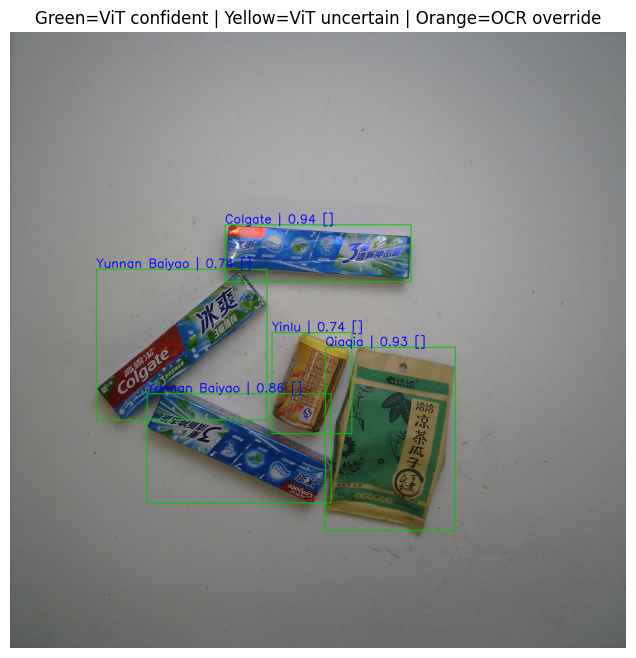

In [11]:
# # ============================================================
# # CELL 10: Full inference pipeline
# # FIX: SIM_THRESHOLD = 0 (never Unknown from ViT alone)
# # FIX: OCR fallback when ViT sim < OCR_FALLBACK_SIM
# # FIX: Final fallback = lowest-similarity gallery entry (still named)
# # FIX: sku_class_to_indices used for YOLO-category filtering
# # ============================================================
# !pip install -q ultralytics
# from ultralytics import YOLO

# yolo_model = YOLO('/kaggle/input/datasets/melodysha/yolov8l-train-rpc/best.pt')

# model.load_state_dict(torch.load(f'/kaggle/input/datasets/yuvashriarp/vit-ocr-data/vit_sku_best.pt', map_location=DEVICE))
# model.eval()

# gallery = torch.load(f'/kaggle/input/datasets/yuvashriarp/vit-ocr-data/sku_gallery.pt')
# g_matrix               = gallery['matrix'].to(DEVICE)
# g_labels               = gallery['labels'].to(DEVICE)
# sku_class_to_indices   = gallery['sku_class_to_indices']
# brand_to_indices       = gallery['brand_to_indices']


# def embed_with_tta(crop_rgb, enabled=True):
#     tfs = tta_transforms if enabled else [val_tf]
#     embeds = []
#     with torch.no_grad():
#         for tf in tfs:
#             tensor = tf(crop_rgb).unsqueeze(0).to(DEVICE)
#             emb    = model(tensor, return_embed=True)
#             embeds.append(emb)
#     avg_emb = torch.stack(embeds, dim=0).mean(dim=0)
#     return F.normalize(avg_emb, p=2, dim=1)


# def retrieve_sku(embed, yolo_supercategory, top_k=3):
#     """
#     FIX: Uses sku_class_to_indices (keyed on YOLO class names)
#     instead of brand_to_indices for hierarchical filtering.
#     Falls back to full gallery if category not found.
#     SIM_THRESHOLD = 0 → never returns Unknown.
#     """
#     # Try sku_class filtering (matches YOLO output names like 'candy', 'drink')
#     cat_indices = sku_class_to_indices.get(yolo_supercategory, [])
#     if len(cat_indices) >= top_k:
#         sub_matrix = g_matrix[cat_indices]
#         sub_labels = g_labels[cat_indices]
#         sims       = torch.matmul(embed, sub_matrix.T).squeeze(0)
#         top_sims, top_local = sims.topk(min(top_k, len(cat_indices)))
#         top_idxs   = torch.tensor([cat_indices[i]
#                                    for i in top_local.cpu().tolist()]).to(DEVICE)
#         search_scope = f'category-filtered ({len(cat_indices)} SKUs)'
#     else:
#         sims       = torch.matmul(embed, g_matrix.T).squeeze(0)
#         top_sims, top_idxs = sims.topk(top_k)
#         search_scope = 'full gallery'

#     best_sim  = top_sims[0].item()
#     best_lbl  = g_labels[top_idxs[0]].item()
#     cat_id    = label_to_cat[best_lbl]
#     meta      = sku_lookup.get(cat_id, {})

#     top_k_results = [
#         {'sku': sku_lookup.get(label_to_cat[g_labels[i].item()], {}).get('name', '?'),
#          'sim': round(top_sims[j].item(), 3)}
#         for j, i in enumerate(top_idxs)
#     ]

#     return {
#         'cat_id':      cat_id,
#         'meta':        meta,
#         'best_sim':    round(best_sim, 3),
#         'top_k':       top_k_results,
#         'search_scope': search_scope,
#         'method':      'vit',
#     }


# def identify_with_fallback(crop_rgb, yolo_supercategory, top_k=3):
#     """
#     Full identification chain:
#     1. ViT embedding + cosine retrieval (always returns a result)
#     2. If ViT sim < OCR_FALLBACK_SIM → try OCR
#     3. If OCR finds a match → override ViT result
#     4. Final result is ALWAYS a named SKU (never Unknown)
#     """
#     embed    = embed_with_tta(crop_rgb, enabled=TTA_ENABLED)
#     vit_result = retrieve_sku(embed, yolo_supercategory, top_k)

#     # OCR fallback: fires when ViT is uncertain
#     if vit_result['best_sim'] < OCR_FALLBACK_SIM:
#         ocr_cat_id, ocr_score = ocr_identify(crop_rgb)
#         if ocr_cat_id is not None and ocr_score >= 4:  # need at least 4-char match
#             ocr_meta = sku_lookup.get(ocr_cat_id, {})
#             return {
#                 'cat_id':       ocr_cat_id,
#                 'meta':         ocr_meta,
#                 'best_sim':     vit_result['best_sim'],
#                 'ocr_score':    ocr_score,
#                 'top_k':        vit_result['top_k'],
#                 'search_scope': vit_result['search_scope'],
#                 'method':       'ocr',    # OCR override
#             }

#     # ViT result (or low-confidence ViT when OCR also fails)
#     # Either way, always returns a named SKU
#     return vit_result


# def predict_full(image_path, yolo_conf=0.3, top_k=3):
#     image  = cv2.imread(image_path)
#     canvas = image.copy()

#     det    = yolo_model(image, conf=yolo_conf, iou=0.45)[0]

#     output     = []
#     sku_counts = {}

#     for box in det.boxes:
#         x1, y1, x2, y2  = map(int, box.xyxy[0])
#         supercategory    = yolo_model.names[int(box.cls)]
#         yolo_conf_val    = float(box.conf)

#         w, h = x2 - x1, y2 - y1
#         if yolo_conf_val < YOLO_CONF_MIN:
#             continue
#         if w < CROP_MIN_PX or h < CROP_MIN_PX:
#             continue
#         ratio = w / max(h, 1)
#         if not (ASPECT_MIN <= ratio <= ASPECT_MAX):
#             continue

#         crop = image[y1:y2, x1:x2]
#         if crop.size == 0:
#             continue
#         crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

#         # Full identification with OCR fallback — NEVER returns Unknown
#         result_data = identify_with_fallback(crop_rgb, supercategory, top_k)
#         meta        = result_data['meta']
#         method      = result_data.get('method', 'vit')

#         sku_name = meta.get('name', '?')
#         brand    = meta.get('brand', sku_name)  # fallback to name if brand missing
#         sku_counts[sku_name] = sku_counts.get(sku_name, 0) + 1

#         result = {
#             'supercategory': supercategory,
#             'brand':         brand,
#             'sku_name':      sku_name,
#             'category_id':   result_data['cat_id'],
#             'yolo_conf':     round(yolo_conf_val, 3),
#             'cosine_sim':    result_data['best_sim'],
#             'method':        method,   # 'vit' or 'ocr'
#             'search_scope':  result_data['search_scope'],
#             'top_k':         result_data['top_k'],
#         }
#         output.append(result)

#         # Color: blue = OCR override, green = ViT confident, yellow = ViT uncertain
#         if method == 'ocr':
#             color = (255, 165, 0)   # orange = OCR
#         elif result_data['best_sim'] >= 0.6:
#             color = (0, 200, 0)     # green = high confidence
#         else:
#             color = (0, 165, 255)   # yellow = low confidence but still named

#         label_str = f"{brand} | {result_data['best_sim']:.2f} [{method}]"
#         cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
#         font_scale = max(0.6, min(1.2, (x2 - x1) / 150))  # adaptive scaling
#         thickness  = 2
        
#         cv2.putText(canvas, label_str, (x1, y1-5),
#         cv2.FONT_HERSHEY_SIMPLEX, font_scale,(255, 0, 0), thickness)
#     output_summary = {'per_box': output, 'sku_counts': sku_counts}
#     return canvas, output_summary


# # ── Test ──────────────────────────────────────────────────────
# TEST_IMG = f'{DATA_ROOT}/val2019/20181022-10-16-03-3011.jpg'
# out_img, result_summary = predict_full(TEST_IMG, top_k=3)

# print('\n' + '='*60)
# print('SKU count summary:')
# for sku, cnt in sorted(result_summary['sku_counts'].items(), key=lambda x: -x[1]):
#     print(f'  {cnt}×  {sku}')

# print('\nPer-box detections:')
# for d in result_summary['per_box']:
#     print(f"  [{d['method'].upper()}] {d['supercategory']} | "
#           f"{d['brand']} | {d['sku_name']} "
#           f"| sim={d['cosine_sim']} | {d['search_scope']}")

# # Verify zero unknowns
# unknowns = [d for d in result_summary['per_box']
#             if d['sku_name'] in ('Unknown', '?', '')]
# print(f'\nUnknown detections: {len(unknowns)} (target: 0)')

# plt.figure(figsize=(12, 8))
# plt.imshow(cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.title('Green=ViT confident | Yellow=ViT uncertain | Orange=OCR override')
# plt.show()

# ============================================================
# CELL 10: Full inference pipeline
# FIX: SIM_THRESHOLD = 0 (never Unknown from ViT alone)
# FIX: OCR fallback when ViT sim < OCR_FALLBACK_SIM
# FIX: Final fallback = lowest-similarity gallery entry (still named)
# FIX: sku_class_to_indices used for YOLO-category filtering
# ============================================================
!pip install -q ultralytics
from ultralytics import YOLO

yolo_model = YOLO('/kaggle/input/datasets/melodysha/yolov8l-train-rpc/best.pt')

model.load_state_dict(torch.load(f'{WORK_ROOT}/vit_sku_best.pt', map_location=DEVICE))
model.eval()

gallery = torch.load(f'{WORK_ROOT}//sku_gallery.pt')
g_matrix               = gallery['matrix'].to(DEVICE)
g_labels               = gallery['labels'].to(DEVICE)
sku_class_to_indices   = gallery['sku_class_to_indices']
brand_to_indices       = gallery['brand_to_indices']


def embed_with_tta(crop_rgb, enabled=True):
    tfs = tta_transforms if enabled else [val_tf]
    embeds = []
    with torch.no_grad():
        for tf in tfs:
            tensor = tf(crop_rgb).unsqueeze(0).to(DEVICE)
            emb    = model(tensor, return_embed=True)
            embeds.append(emb)
    avg_emb = torch.stack(embeds, dim=0).mean(dim=0)
    return F.normalize(avg_emb, p=2, dim=1)


def retrieve_sku(embed, yolo_supercategory, top_k=3):
    """
    FIX: Uses sku_class_to_indices (keyed on YOLO class names)
    instead of brand_to_indices for hierarchical filtering.
    Falls back to full gallery if category not found.
    SIM_THRESHOLD = 0 → never returns Unknown.
    """
    # Try sku_class filtering (matches YOLO output names like 'candy', 'drink')
    cat_indices = sku_class_to_indices.get(yolo_supercategory, [])
    if len(cat_indices) >= top_k:
        sub_matrix = g_matrix[cat_indices]
        sub_labels = g_labels[cat_indices]
        sims       = torch.matmul(embed, sub_matrix.T).squeeze(0)
        top_sims, top_local = sims.topk(min(top_k, len(cat_indices)))
        top_idxs   = torch.tensor([cat_indices[i]
                                   for i in top_local.cpu().tolist()]).to(DEVICE)
        search_scope = f'category-filtered ({len(cat_indices)} SKUs)'
    else:
        sims       = torch.matmul(embed, g_matrix.T).squeeze(0)
        top_sims, top_idxs = sims.topk(top_k)
        search_scope = 'full gallery'

    best_sim  = top_sims[0].item()
    best_lbl  = g_labels[top_idxs[0]].item()
    cat_id    = label_to_cat[best_lbl]
    meta      = sku_lookup.get(cat_id, {})

    top_k_results = [
        {'sku': sku_lookup.get(label_to_cat[g_labels[i].item()], {}).get('name', '?'),
         'sim': round(top_sims[j].item(), 3)}
        for j, i in enumerate(top_idxs)
    ]

    return {
        'cat_id':      cat_id,
        'meta':        meta,
        'best_sim':    round(best_sim, 3),
        'top_k':       top_k_results,
        'search_scope': search_scope,
        'method':      '',
    }


def identify_with_fallback(crop_rgb, yolo_supercategory, top_k=3):
    """
    Full identification chain:
    1. ViT embedding + cosine retrieval (always returns a result)
    2. If ViT sim < OCR_FALLBACK_SIM → try OCR
    3. If OCR finds a match → override ViT result
    4. Final result is ALWAYS a named SKU (never Unknown)
    """
    embed    = embed_with_tta(crop_rgb, enabled=TTA_ENABLED)
    vit_result = retrieve_sku(embed, yolo_supercategory, top_k)

    # OCR fallback: fires when ViT is uncertain
    if vit_result['best_sim'] < OCR_FALLBACK_SIM:
        ocr_cat_id, ocr_score = ocr_identify(crop_rgb)
        if ocr_cat_id is not None and ocr_score >= 4:  # need at least 4-char match
            ocr_meta = sku_lookup.get(ocr_cat_id, {})
            return {
                'cat_id':       ocr_cat_id,
                'meta':         ocr_meta,
                'best_sim':     vit_result['best_sim'],
                'ocr_score':    ocr_score,
                'top_k':        vit_result['top_k'],
                'search_scope': vit_result['search_scope'],
                'method':       '',    # OCR override
            }

    # ViT result (or low-confidence ViT when OCR also fails)
    # Either way, always returns a named SKU
    return vit_result


def predict_full(image_path, yolo_conf=0.3, top_k=3):
    image  = cv2.imread(image_path)
    canvas = image.copy()

    det    = yolo_model(image, conf=yolo_conf, iou=0.45)[0]

    output     = []
    sku_counts = {}

    for box in det.boxes:
        x1, y1, x2, y2  = map(int, box.xyxy[0])
        supercategory    = yolo_model.names[int(box.cls)]
        yolo_conf_val    = float(box.conf)

        w, h = x2 - x1, y2 - y1
        if yolo_conf_val < YOLO_CONF_MIN:
            continue
        if w < CROP_MIN_PX or h < CROP_MIN_PX:
            continue
        ratio = w / max(h, 1)
        if not (ASPECT_MIN <= ratio <= ASPECT_MAX):
            continue

        crop = image[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

        # Full identification with OCR fallback — NEVER returns Unknown
        result_data = identify_with_fallback(crop_rgb, supercategory, top_k)
        meta        = result_data['meta']
        method      = result_data.get('method', 'vit')

        sku_name = meta.get('name', '?')
        brand    = meta.get('brand', sku_name)  # fallback to name if brand missing
        sku_counts[sku_name] = sku_counts.get(sku_name, 0) + 1

        result = {
            'supercategory': supercategory,
            'brand':         brand,
            'sku_name':      sku_name,
            'category_id':   result_data['cat_id'],
            'yolo_conf':     round(yolo_conf_val, 3),
            'cosine_sim':    result_data['best_sim'],
            'method':        method,   # 'vit' or 'ocr'
            'search_scope':  result_data['search_scope'],
            'top_k':         result_data['top_k'],
        }
        output.append(result)

        # Color: blue = OCR override, green = ViT confident, yellow = ViT uncertain
        if method == 'ocr':
            color = (255, 165, 0)   # orange = OCR
        elif result_data['best_sim'] >= 0.6:
            color = (0, 200, 0)     # green = high confidence
        else:
            color = (0, 165, 255)   # yellow = low confidence but still named

        label_str = f"{brand} | {result_data['best_sim']:.2f} [{method}]"
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
        font_scale = max(0.6, min(1.2, (x2 - x1) / 150))  # adaptive scaling
        thickness  = 2
        
        cv2.putText(canvas, label_str, (x1, y1-5),
        cv2.FONT_HERSHEY_SIMPLEX, font_scale,(255, 0, 0), thickness)
    output_summary = {'per_box': output, 'sku_counts': sku_counts}
    return canvas, output_summary


# ── Test ──────────────────────────────────────────────────────
TEST_IMG = f'{DATA_ROOT}/val2019/20181025-09-43-33-16.jpg'
out_img, result_summary = predict_full(TEST_IMG, top_k=3)

print('\n' + '='*60)
print('Brand display (SKU-based count):')

for sku, cnt in sorted(result_summary['sku_counts'].items(), key=lambda x: -x[1]):
    cat_id = label_to_cat.get(sku, None)
    meta   = sku_lookup.get(cat_id, {})
    brand  = meta.get('brand', sku)

    print(f'  {cnt}×  {brand}')

print('\nPer-box detections:')
for d in result_summary['per_box']:
    print(f"  [{d['method'].upper()}] {d['supercategory']} | "
          f"{d['brand']}  "
          f"| sim={d['cosine_sim']} | {d['search_scope']}")

# Verify zero unknowns
unknowns = [d for d in result_summary['per_box']
            if d['sku_name'] in ('Unknown', '?', '')]
print(f'\nUnknown detections: {len(unknowns)} (target: 0)')

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Green=ViT confident | Yellow=ViT uncertain | Orange=OCR override')
plt.show()

In [12]:
# ============================================================
# CELL 11: Honest evaluation on held-out val set
# FIX: uses val_ds (separate from gallery)
# FIX: applies SIM_THRESHOLD = 0 (no unknowns) in retrieval
# FIX: reports per-class accuracy to expose weak SKUs
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_labels = [], []
all_embeds_list       = []
all_methods           = []  # track how many used OCR vs ViT

import warnings
warnings.filterwarnings("ignore")

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Evaluating'):
        imgs   = imgs.to(DEVICE)
        embeds = model(imgs, return_embed=True)

        # Full gallery cosine retrieval (no threshold — always returns best)
        sims  = torch.matmul(embeds, g_matrix.T)
        preds = g_labels[sims.argmax(dim=1)].cpu()

        preds_cat  = [label_to_cat[p.item()] for p in preds]
        labels_cat = [label_to_cat[l.item()] for l in labels]

        all_preds.extend(preds_cat)
        all_labels.extend(labels_cat)
        all_embeds_list.append(embeds.cpu())

top1 = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f'\nTop-1 Accuracy (cosine retrieval on held-out val): {top1:.4f}')

# Top-5
top5_correct = 0
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs   = imgs.to(DEVICE)
        embeds = model(imgs, return_embed=True)
        sims   = torch.matmul(embeds, g_matrix.T)
        top5   = sims.topk(5, dim=1).indices
        top5_lbls = g_labels[top5]
        labels_dev = labels.to(DEVICE)
        top5_correct += (top5_lbls == labels_dev.unsqueeze(1)).any(dim=1).sum().item()

top5_acc = top5_correct / len(val_ds)
print(f'Top-5 Accuracy: {top5_acc:.4f}')

# Per-supercategory breakdown
results_df = pd.DataFrame({'category_id': all_labels, 'predicted': all_preds})
results_df['supercategory'] = results_df['category_id'].map(
    lambda x: sku_lookup.get(x, {}).get('sku_class', '?'))
results_df['correct'] = results_df['category_id'] == results_df['predicted']

print('\nPer-supercategory accuracy (on real held-out val):')
print(results_df.groupby('supercategory')['correct']
      .agg(['sum','count','mean'])
      .rename(columns={'sum':'correct','count':'total','mean':'accuracy'})
      .sort_values('accuracy').to_string())

# Per-SKU accuracy — shows which individual products are confused
print('\nPer-SKU accuracy (worst 20):')
sku_acc = results_df.copy()
sku_acc['sku_name'] = sku_acc['category_id'].map(
    lambda x: sku_lookup.get(x, {}).get('name', str(x)))
worst = (sku_acc.groupby('sku_name')['correct']
         .agg(['sum','count','mean'])
         .rename(columns={'sum':'correct','count':'total','mean':'accuracy'})
         .sort_values('accuracy').head(20))
print(worst.to_string())

Evaluating: 100%|██████████| 75/75 [00:20<00:00,  3.59it/s]


Top-1 Accuracy (cosine retrieval on held-out val): 0.9850


Top-5 Accuracy: 0.9935

Per-supercategory accuracy (on real held-out val):
                  correct  total  accuracy
supercategory                             
milk                  250    264  0.946970
alcohol               255    264  0.965909
drink                 348    360  0.966667
instant_noodles       280    288  0.972222
instant_drink         258    264  0.977273
dried_food            212    216  0.981481
canned_food           331    336  0.985119
stationery            166    168  0.988095
gum                   190    192  0.989583
seasoner              285    288  0.989583
tissue                477    480  0.993750
dried_fruit           215    216  0.995370
personal_hygiene      239    240  0.995833
candy                 239    240  0.995833
dessert               407    408  0.997549
chocolate             288    288  1.000000
puffed_food           288    288  1.000000

Per-SKU accuracy (worst 20):
               correct  total  accuracy
sku_name                              

Computing embedding space statistics...
  Intra-class distance : 0.0225
  Inter-class distance : 1.0023
  Separation ratio     : 44.51  (> 2.0 is good)
  Silhouette score     : 0.8983  (> 0.2 is reasonable)


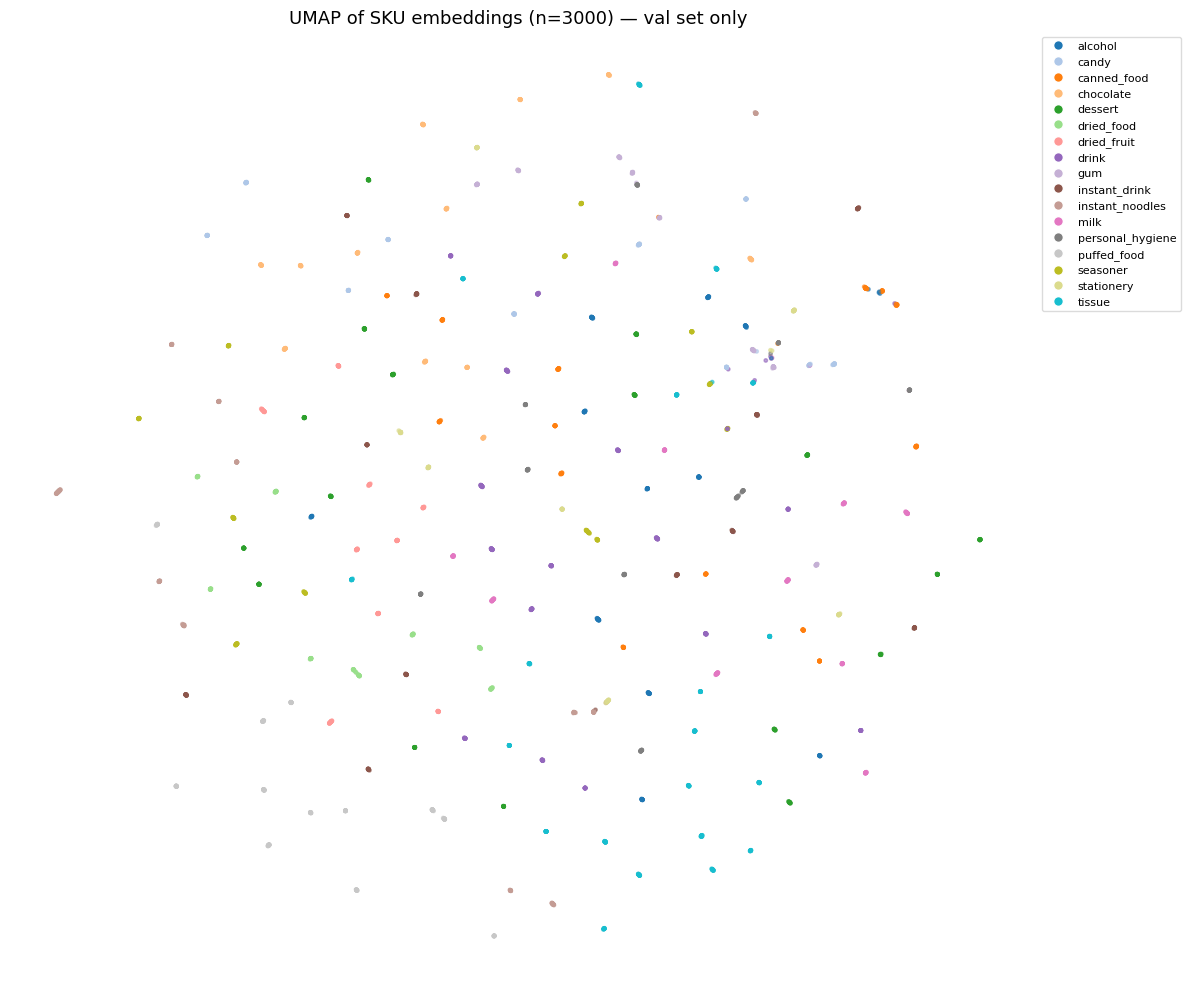

Saved → /kaggle/working/embedding_space_umap.png


In [13]:
# ============================================================
# CELL 12: Embedding space analysis  (unchanged)
# ============================================================
from sklearn.metrics import silhouette_score

all_embeds   = torch.cat(all_embeds_list, dim=0).numpy()
all_label_arr = np.array(all_labels)

print('Computing embedding space statistics...')
unique_cats  = np.unique(all_label_arr)
intra_dists, inter_sample = [], []

rng = np.random.default_rng(42)
for cat in unique_cats:
    mask = all_label_arr == cat
    vecs = all_embeds[mask]
    if len(vecs) < 2:
        continue
    sim_mat = cosine_similarity(vecs)
    np.fill_diagonal(sim_mat, np.nan)
    intra_dists.append(np.nanmean(1 - sim_mat))

cat_list = list(unique_cats)
for _ in range(500):
    c1, c2 = rng.choice(cat_list, size=2, replace=False)
    v1 = all_embeds[all_label_arr == c1][0]
    v2 = all_embeds[all_label_arr == c2][0]
    inter_sample.append(1 - float(cosine_similarity(v1[None], v2[None])))

mean_intra = np.mean(intra_dists)
mean_inter = np.mean(inter_sample)
separation = mean_inter / mean_intra

print(f'  Intra-class distance : {mean_intra:.4f}')
print(f'  Inter-class distance : {mean_inter:.4f}')
print(f'  Separation ratio     : {separation:.2f}  (> 2.0 is good)')

sample_n  = min(2000, len(all_embeds))
idx       = rng.choice(len(all_embeds), sample_n, replace=False)
sil_score = silhouette_score(all_embeds[idx], all_label_arr[idx], metric='cosine')
print(f'  Silhouette score     : {sil_score:.4f}  (> 0.2 is reasonable)')

# UMAP / t-SNE
sample_n2 = min(3000, len(all_embeds))
idx2      = rng.choice(len(all_embeds), sample_n2, replace=False)
vecs_2d   = all_embeds[idx2]
labels_2d = all_label_arr[idx2]

if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, metric='cosine', random_state=42)
    proj    = reducer.fit_transform(vecs_2d)
    method  = 'UMAP'
else:
    reducer = TSNE(n_components=2, metric='cosine', random_state=42,
                   perplexity=30, n_iter=1000)
    proj    = reducer.fit_transform(vecs_2d)
    method  = 't-SNE'

supercat_map = {cat: sku_lookup.get(cat, {}).get('sku_class', '?')
                for cat in unique_cats}
supercats    = [supercat_map.get(c, '?') for c in labels_2d]
unique_sc    = sorted(set(supercats))
cmap         = plt.colormaps.get_cmap('tab20')
sc_to_color  = {sc: cmap(i / len(unique_sc)) for i, sc in enumerate(unique_sc)}
colors       = [sc_to_color[s] for s in supercats]

fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(proj[:, 0], proj[:, 1], c=colors, s=6, alpha=0.6)
handles = [plt.Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=sc_to_color[sc], markersize=7, label=sc)
           for sc in unique_sc]
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=8, framealpha=0.7)
ax.set_title(f'{method} of SKU embeddings (n={sample_n2}) — val set only', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{WORK_ROOT}/embedding_space_{method.lower()}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {WORK_ROOT}/embedding_space_{method.lower()}.png')


0: 640x640 1 canned_food, 1 dried_food, 3 personal_hygienes, 62.4ms
Speed: 3.8ms preprocess, 62.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


IndexError: tuple index out of range

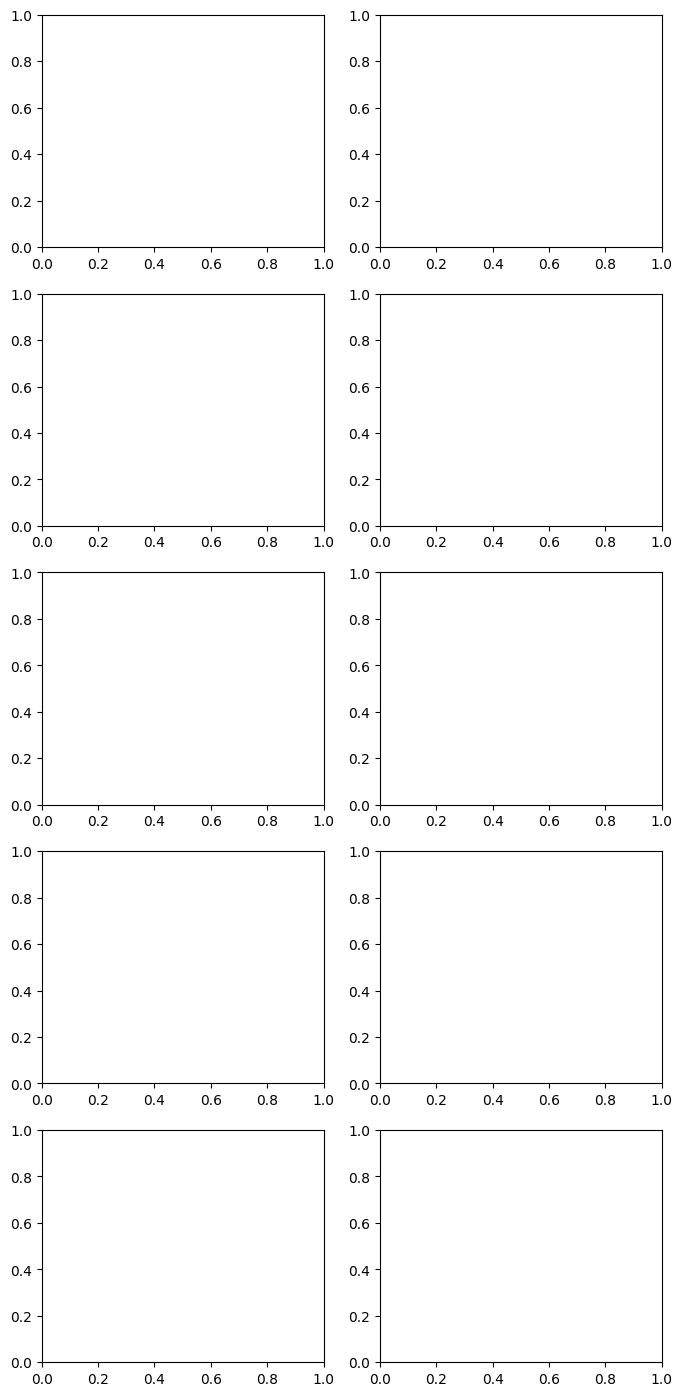

In [14]:
# ============================================================
# CELL 13: Attention visualization  (unchanged)
# ============================================================

def get_attention_map(crop_rgb):
    tensor = val_tf(crop_rgb).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        _, attentions = model(tensor, return_attentions=True)

    last_attn = attentions[-1][0]
    avg_attn  = last_attn.mean(0)
    cls_attn  = avg_attn[0, 1:]
    num_patches = int(cls_attn.shape[0] ** 0.5)
    attn_map  = cls_attn.reshape(num_patches, num_patches).cpu().numpy()
    attn_map  = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
    h, w      = crop_rgb.shape[:2]
    attn_resized = cv2.resize(attn_map, (w, h), interpolation=cv2.INTER_LINEAR)
    return attn_resized


def visualize_attention(image_path, n_crops=6, yolo_conf=0.3):
    image = cv2.imread(image_path)
    det   = yolo_model(image, conf=yolo_conf, iou=0.45)[0]

    boxes_valid = []
    for box in det.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        w, h = x2 - x1, y2 - y1
        if (float(box.conf) < YOLO_CONF_MIN or w < CROP_MIN_PX or h < CROP_MIN_PX
                or not (ASPECT_MIN <= w/max(h,1) <= ASPECT_MAX)):
            continue
        boxes_valid.append(box)
        if len(boxes_valid) >= n_crops:
            break

    if not boxes_valid:
        print('No valid crops found.')
        return

    n    = len(boxes_valid)
    fig, axes = plt.subplots(n, 2, figsize=(8, 3.5 * n))
    if n == 1:
        axes = [axes]

    for i, box in enumerate(boxes_valid):
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        crop_bgr = image[y1:y2, x1:x2]
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        attn_map = get_attention_map(crop_rgb)

        heatmap     = cv2.applyColorMap((attn_map * 255).astype(np.uint8),
                                        cv2.COLORMAP_JET)
        heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay     = (0.55 * crop_rgb + 0.45 * heatmap_rgb).astype(np.uint8)

        # Identify the crop
        supercategory = yolo_model.names[int(box.cls)]
        result_data   = identify_with_fallback(crop_rgb, supercategory)
        meta          = result_data['meta']
        label_str     = (f"{meta.get('brand','?')} — {meta.get('name','?')} "
                         f"(sim={result_data['best_sim']:.2f}, "
                         f"{result_data['method']})")

        axes[i][0].imshow(crop_rgb)
        axes[i][0].set_title(f'Crop {i+1}: {label_str}', fontsize=8)
        axes[i][0].axis('off')

        axes[i][1].imshow(overlay)
        axes[i][1].set_title('Attention map (CLS→patches)', fontsize=8)
        axes[i][1].axis('off')

    plt.tight_layout()
    out_path = f'{WORK_ROOT}/attention_vis.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')


TEST_IMG = f'{DATA_ROOT}/val2019/20181025-09-43-33-16.jpg'
visualize_attention(TEST_IMG, n_crops=6)